In [10]:
import os
import sys
sys.path.append(os.path.abspath('..'))


# Import packages

In [ ]:
from galaxy_source.galaxy_cnn import GalaxyCNN
from galaxy_source.galaxy_dataset import GalaxyDataset
from galaxy_source.transformed_subset import TransformedSubset
from torch.utils.data import Dataset
from galaxy_source.galaxy_loader import GalaxyDataLoader
from galaxy_source.galaxy_train import GalaxyTrainer
from torch.utils.data import DataLoader


import torch
from torchvision import transforms
from torch.utils.data import random_split

# Import dataset and split to test and train

In [12]:
dataset = GalaxyDataset("../data/Galaxy10_DECals.h5")  

test_ratio = 0.25
test_size = int(len(dataset) * test_ratio)
train_size = len(dataset) - test_size


In [ ]:
from torchvision import transforms
import torch

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(180),

    transforms.RandomResizedCrop(
        size=256,
        scale=(0.6, 1.0),   
        ratio=(0.9, 1.1)
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
])


test_transforms = transforms.Compose([]) 


In [22]:
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [23]:
train_dataset = TransformedSubset(train_dataset, transform=train_transforms)
test_dataset = TransformedSubset(test_dataset, transform=test_transforms)

# Train CNN

In [26]:
trainer = GalaxyTrainer()

In [27]:
trainer.train(train_dataset, test_dataset, num_epochs=50, batch_size=64)

C:\Users\Anya\AppData\Local\Temp\ipykernel_10724\2731409772.py:81: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(self.device.type == "cuda"))
Epoch 1:   0%|          | 0/208 [00:00<?, ?it/s]C:\Users\Anya\AppData\Local\Temp\ipykernel_10724\2731409772.py:106: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(self.device.type == "cuda")):
Epoch 1: 100%|██████████| 208/208 [06:56<00:00,  2.00s/it]
C:\Users\Anya\AppData\Local\Temp\ipykernel_10724\2731409772.py:134: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(self.device.type == "cuda")):


Epoch 1/50 | Train Loss: 1.2490, Train Acc: 0.5105 | Val Loss: 1.1509, Val Acc: 0.6209 | Best: 0.6209


Epoch 2: 100%|██████████| 208/208 [06:55<00:00,  2.00s/it]


Epoch 2/50 | Train Loss: 1.1023, Train Acc: 0.6222 | Val Loss: 1.1159, Val Acc: 0.5636 | Best: 0.6209


Epoch 3: 100%|██████████| 208/208 [08:21<00:00,  2.41s/it]


...

Epoch 18: 100%|██████████| 208/208 [06:59<00:00,  2.01s/it]


Epoch 18/50 | Train Loss: 0.7252, Train Acc: 0.8287 | Val Loss: 0.7330, Val Acc: 0.8182 | Best: 0.8200


Epoch 19: 100%|██████████| 208/208 [07:47<00:00,  2.25s/it]


Early stopping triggered


GalaxyCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), paddi

In [29]:
model = GalaxyCNN()
model.load_model("../models/best_0.8200.pth")

In [30]:
test_loader = DataLoader(
            test_dataset,
            batch_size=1,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )


In [32]:
class_names = ["Disturbed / Merging", "Smooth", "Spiral", "Edge-on"]


🔥 FINAL METRICS
Accuracy:  0.8198
F1-score:  0.8038
Precision: 0.8012
Recall:    0.8165

📊 Classification Report:

                     precision    recall  f1-score   support

Disturbed / Merging       0.69      0.61      0.65       734
             Smooth       0.80      0.91      0.85      1229
             Spiral       0.91      0.77      0.83      1666
            Edge-on       0.80      0.97      0.88       805

           accuracy                           0.82      4434
          macro avg       0.80      0.82      0.80      4434
       weighted avg       0.82      0.82      0.82      4434



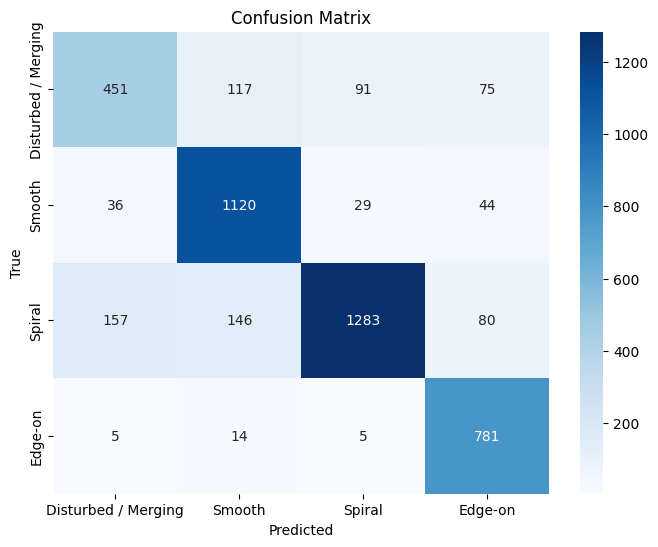

{'accuracy': 0.8198015336039693,
 'f1': 0.8037566905786332,
 'precision': 0.8011983969322202,
 'recall': 0.8165114509128607}

In [33]:
trainer.evaluate_metrics(model, test_loader, class_names)

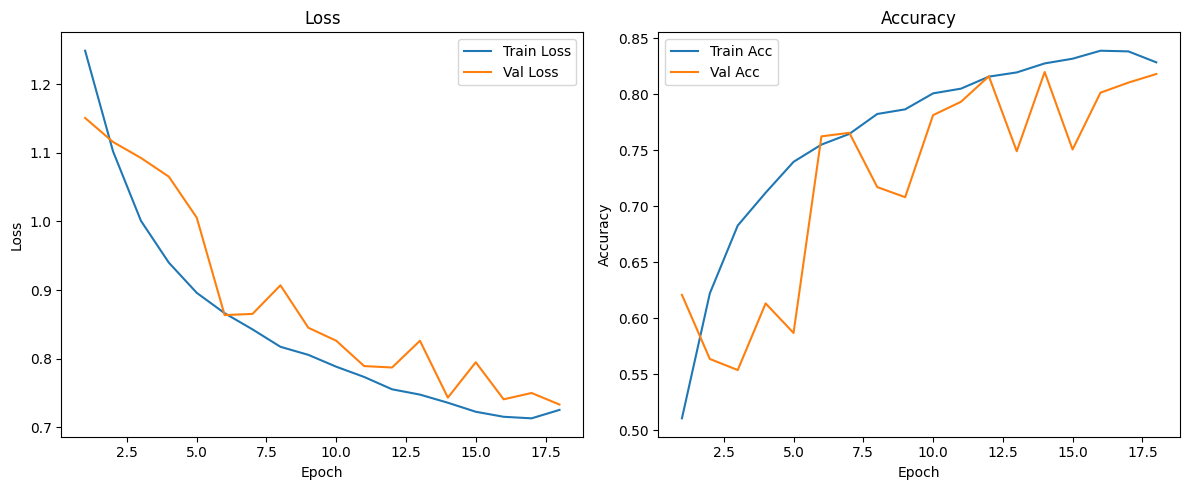

In [34]:
trainer.plot_metrics()

In [ ]:
from galaxy_source.galaxy_loader import GalaxyDataLoader

In [36]:
gdl = GalaxyDataLoader(class_names)

In [37]:
device = "cuda" if torch.cuda.is_available else "cpu"

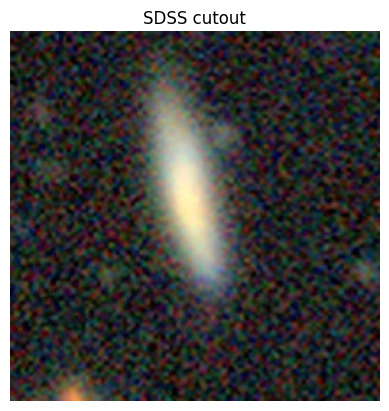

In [56]:
import matplotlib.pyplot as plt

ra = 124.7985
dec =  23.2233
pixscale = 0.1


img = gdl.get_legacy_image(ra, dec, pixscale=pixscale)

plt.imshow(img)
plt.title("SDSS cutout")
plt.axis("off")
plt.show()


In [57]:
img, pred, conf = gdl.classify_legacy(model, ra, dec, pixscale=pixscale)

Predicted: Edge-on
Confidence: 0.7657


In [41]:
img, pred, conf = gdl.classify_local(model, "images.jpg")

Predicted: Edge-on
Confidence: 0.9885
